# Drought Monitoring and Early Warning

This notebook runs the `drought` module for a northern Kenya AOI. It produces
Composite Drought Index (CDI) statistics, annual severity layers, drought
sub-index time series, spatial typology, uncertainty information, and a
six-month forecast.

A long historical period is intentional: drought baselines and trends are more
useful with at least 5 years of data, and preferably 10–30 years.


## Before you run

1. Install the project with `uv sync --all-extras` or `pip install -e ".[all,dev]"`.
2. Authenticate Earth Engine with `earthengine authenticate`.
3. Set `GEE_PROJECT` in your environment or repository `.env`.

Earth Engine downloads and LSTM training can take several minutes.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError(
        "Set GEE_PROJECT in your shell or in the repository .env file before running this notebook."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
module_info = USE_CASE_REGISTRY["drought"]
print(module_info.name)
print(module_info.date_guidance)
print("Models:", [option.id for option in module_info.model_options])

Drought Monitoring & Early Warning
Select 10–30 years for climatological baseline. Minimum 5 years for trend detection.
Models: ['lstm', 'drought_monitoring']


In [3]:
# Approximate bounding polygon around Marsabit County, Kenya.
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [36.00, 1.00],
            [38.20, 1.00],
            [38.20, 3.70],
            [36.00, 3.70],
            [36.00, 1.00],
        ]
    ],
}

analysis_args = {
    "module": "drought",
    "aoi_geojson": aoi,
    "start_date": "2005-01-01",
    "end_date": "2024-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "lstm",  # or "drought_monitoring"
        "output_dir": str(OUTPUT_DIR),
    },
}

In [4]:
# Jupyter supports top-level await.
output = await run_analysis(**analysis_args)

2026-06-24 13:55:19,737 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-06-24 13:55:19,753 - distributed.scheduler - INFO - State start
2026-06-24 13:55:19,754 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-hrptm9pa', purging
2026-06-24 13:55:19,757 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:38239
2026-06-24 13:55:19,757 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-06-24 13:55:19,758 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-24 13:55:19,768 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:40021'
2026-06-24 13:55:19,770 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:44297'
2026-06-24 13:55:19,773 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:39995'
2026-06

✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif  (19 bands, 27×22 px, 0.13 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif  (19 bands, 27×22 px, 0.13 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif  (19 bands, 27×22 px, 0.14 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_CDI.tif  (19 bands, 27×22 px, 0.13 MB)


In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Chart keys:", sorted(output.charts))
print("Metadata:", output.metadata)
output.stats

Module: drought
Raster output: {'PDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif', 'TDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif', 'VDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif', 'CDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_CDI.tif'}
GeoJSON features: 80
Chart keys: ['anomaly', 'forecast', 'seasonal', 'severity_distribution', 'temporal_severity_distribution', 'timeseries', 'training', 'typology', 'uncertainty']
Metadata: {'model': 'drought-monitoring CDI + lstm', 'package_version': '0.1.7', 'country': 'Kenya', 'start_date': '2005-01-01', 'end_date': '2024-12-31', 'raster': {'PDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif', 'TDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif', 'VDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif', 'CDI'

{'model_type': 'lstm',
 'analysis_year': 2023,
 'mean_cdi': 0.7675,
 'latest_mean_cdi': 0.7966,
 'aoi_valid_pixel_count': 594,
 'extreme_pct': 0.5,
 'severe_pct': 7.4,
 'moderate_pct': 42.3,
 'mild_pct': 33.3,
 'near_normal_pct': 15.0,
 'mild_wet_pct': 0.2,
 'moderately_wet_pct': 0.2,
 'very_wet_pct': 1.2,
 'lstm_mae': 0.1469978541135788,
 'lstm_rmse': 0.186598539352417,
 'lstm_best_val_mse': 0.02973397821187973,
 'stopped_epoch': 23,
 'country': 'Kenya'}

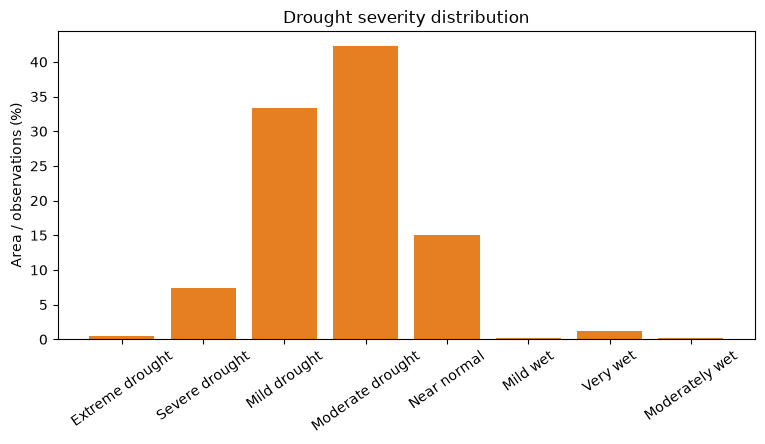

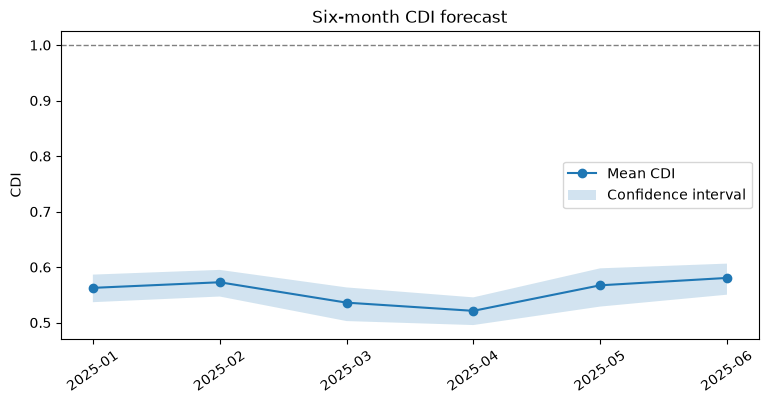

In [6]:
severity = output.charts.get("severity_distribution", {})
if severity.get("labels"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(severity["labels"], severity["data"], color="#E67E22")
    ax.set_ylabel("Area / observations (%)")
    ax.set_title("Drought severity distribution")
    ax.tick_params(axis="x", rotation=35)
    plt.show()

forecast = output.charts.get("forecast", {})
if forecast.get("dates") and forecast.get("mean"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(forecast["dates"], forecast["mean"], marker="o", label="Mean CDI")
    if forecast.get("ci_lower") and forecast.get("ci_upper"):
        ax.fill_between(
            forecast["dates"],
            forecast["ci_lower"],
            forecast["ci_upper"],
            alpha=0.2,
            label="Confidence interval",
        )
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
    ax.set_title("Six-month CDI forecast")
    ax.set_ylabel("CDI")
    ax.tick_params(axis="x", rotation=35)
    ax.legend()
    plt.show()

In [8]:
# Optional: generate a PDF report in a second call.
# Set this to True only when you want the extra analysis/report run.
GENERATE_REPORT = False

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/drought_20260624_105607.pdf
